In [ ]:
# !pip install torch torchvision torchaudio transformers accelerate bitsandbytes --quiet
# !pip install -U bitsandbytes

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os
import random
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings("ignore")

from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

In [ ]:
drive.mount('/content/drive')

drive_folder = "/content/drive/MyDrive/Aireen Y4S1/WIE3007 DATA MINING AND WAREHOUSING/Group Assignment 15%"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Setup huggingface token
from google.colab import userdata
HUGGINGFACE_TOKEN = userdata.get("HF_TOKEN")

from huggingface_hub import login
login(token=HUGGINGFACE_TOKEN)

In [36]:
preprocessed_df = pd.read_csv(os.path.join(drive_folder, "preprocessed_data.csv"))

# Feature Scaling

In [37]:
preprocessed_df.drop(columns=['Sentiment_Score'], inplace=True)
preprocessed_df.drop(columns=['LoanPurposeDescription'], inplace=True)

In [38]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CustomerID                           1000 non-null   int64  
 1   Age                                  1000 non-null   int64  
 2   Education                            1000 non-null   float64
 3   EmploymentLengthYears                1000 non-null   int64  
 4   MonthlyIncome                        1000 non-null   float64
 5   Dependents                           1000 non-null   int64  
 6   CreditScore                          1000 non-null   int64  
 7   ExistingLoans                        1000 non-null   int64  
 8   MonthlyDebt                          1000 non-null   float64
 9   YearsWithBank                        1000 non-null   int64  
 10  HasSavingsAccount                    1000 non-null   int64  
 11  HasCheckingAccount             

In [39]:
X = preprocessed_df.drop("LoanDefault", axis=1)
y = preprocessed_df["LoanDefault"]

numerical_cols = ["Age", "EmploymentLengthYears", "MonthlyIncome", "Dependents", "CreditScore", "ExistingLoans", "MonthlyDebt", "YearsWithBank", "LoanAmount", "LoanTermMonths", "InterestRate" ]

In [40]:
X_standardized = X.copy()

standard_scaler = StandardScaler()

X_standardized[numerical_cols] = standard_scaler.fit_transform(X[numerical_cols])

print("Standardization using StandardScaler")
print(f"Shape: {X_standardized.shape}")

# See before and after
print("\nBefore Standardization:")
print(X[numerical_cols].head(10))
print("\nAfter Standardization:")
print(X_standardized[numerical_cols].head(10))

Standardization using StandardScaler
Shape: (1000, 46)

Before Standardization:
   Age  EmploymentLengthYears  MonthlyIncome  Dependents  CreditScore  \
0   59                     11    9067.159786           2          770   
1   51                     24    5068.058742           1          698   
2   24                      0    2557.541824           0          480   
3   25                      0    7535.097299           0          774   
4   25                      5    4798.465251           2          590   
5   18                      0    2715.312586           0          576   
6   26                      2    8468.695614           2          648   
7   23                      0    2079.184097           3          581   
8   46                      8    9386.927084           0          688   
9   39                     13    9241.197498           2          655   

   ExistingLoans  MonthlyDebt  YearsWithBank    LoanAmount  LoanTermMonths  \
0              3  1583.065500         

In [ ]:
# X_normalized = X.copy()

# min_max_scaler = MinMaxScaler()

# X_normalized[numerical_cols] = min_max_scaler.fit_transform(X[numerical_cols])

# print("Normalization using MinMaxScaler")
# print(f"Shape: {X_normalized.shape}")

# # See before and after
# print("\nBefore Normalization:")
# print(X[numerical_cols].head(10))
# print("\nAfter Normalization:")
# print(X_normalized[numerical_cols].head(10))

# Model Development

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.2, random_state=42, stratify=y)

## Overfitting Model

In [42]:
# Train overfitting model
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [43]:
# Evaluate overfitting model
y_train_pred_knn1 = knn_1.predict(X_train)
y_test_pred_knn1 = knn_1.predict(X_test)

train_accuracy_knn1 = accuracy_score(y_train, y_train_pred_knn1)
test_accuracy_knn1 = accuracy_score(y_test, y_test_pred_knn1)

print(f"OVERFITTING MODEL:")
print(f"Train Accuracy: {train_accuracy_knn1:.4f}")
print(f"Test Accuracy: {test_accuracy_knn1:.4f}")
print(f"Overfitting Gap: {(train_accuracy_knn1 - test_accuracy_knn1):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train, y_train_pred_knn1))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_knn1))

OVERFITTING MODEL:
Train Accuracy: 1.0000
Test Accuracy: 0.6200
Overfitting Gap: 0.3800

Classification Report (Training):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.64      0.54      0.59       100
           1       0.60      0.70      0.65       100

    accuracy                           0.62       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.62      0.62      0.62       200



## Optimal Model

### Adjust k

In [59]:
k = 3

In [60]:
knn_adjusted = KNeighborsClassifier(n_neighbors=k)
knn_adjusted.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

MANUALLY ADJUSTED KNN MODEL:
Train Accuracy: 0.7788
Test Accuracy: 0.6650
Overfitting Gap: 0.1138

Classification Report (Training):
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       400
           1       0.79      0.75      0.77       400

    accuracy                           0.78       800
   macro avg       0.78      0.78      0.78       800
weighted avg       0.78      0.78      0.78       800


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.68      0.63      0.65       100
           1       0.65      0.70      0.68       100

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200


Confusion Matrix:


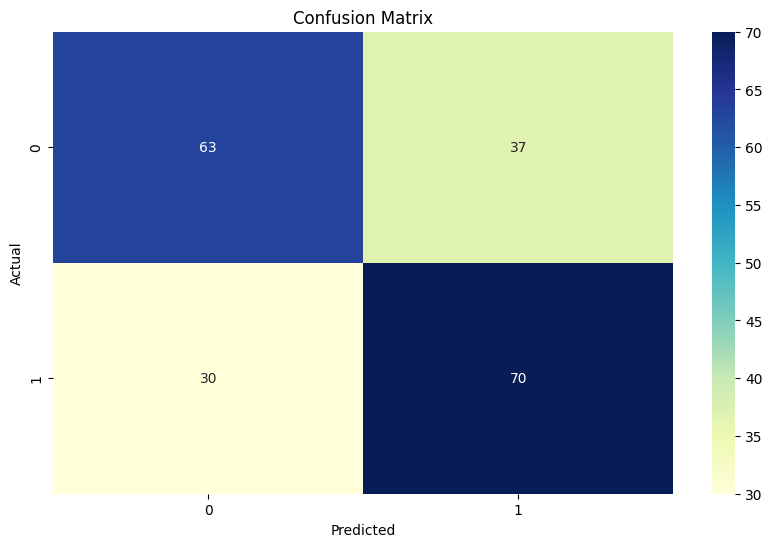

In [61]:
y_train_pred_knn_adjusted = knn_adjusted.predict(X_train)
y_test_pred_knn_adjusted = knn_adjusted.predict(X_test)

train_accuracy_knn_adjusted = accuracy_score(y_train, y_train_pred_knn_adjusted)
test_accuracy_knn_adjusted = accuracy_score(y_test, y_test_pred_knn_adjusted)

print(f"MANUALLY ADJUSTED KNN MODEL:")
print(f"Train Accuracy: {train_accuracy_knn_adjusted:.4f}")
print(f"Test Accuracy: {test_accuracy_knn_adjusted:.4f}")
print(f"Overfitting Gap: {(train_accuracy_knn_adjusted - test_accuracy_knn_adjusted):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train, y_train_pred_knn_adjusted))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_knn_adjusted))

cm = confusion_matrix(y_test, y_test_pred_knn_adjusted)
print("\nConfusion Matrix:")
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

k=1
Train Accuracy: 1.0000
Test Accuracy: 0.6200
Overfitting Gap: 0.3800

k=2
Train Accuracy: 0.7887
Test Accuracy: 0.6250
Overfitting Gap: 0.1637

k=3
Train Accuracy: 0.7788
Test Accuracy: 0.6650
Overfitting Gap: 0.1138

k=4
Train Accuracy: 0.7450
Test Accuracy: 0.6150
Overfitting Gap: 0.1300

k=5
Train Accuracy: 0.7388
Test Accuracy: 0.6050
Overfitting Gap: 0.1338

k=9
Train Accuracy: 0.6713
Test Accuracy: 0.5500
Overfitting Gap: 0.1212

k=13
Train Accuracy: 0.6400
Test Accuracy: 0.5400
Overfitting Gap: 0.1000

k=17
Train Accuracy: 0.6138
Test Accuracy: 0.5200
Overfitting Gap: 0.0938

### Grid Search

In [71]:
# Hyperparameter tuning

# Define parameter grid
# param_grid = {
#     "n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 51],
#     "weights": ["uniform", "distance"],
#     "metric": ["euclidean", "manhattan", "minkowski"]
# }

# param_grid = {
#     "n_neighbors": [5, 7, 9, 11, 15, 21],
#     "weights": ["uniform"],  # reduce overfitting
#     "metric": ["minkowski"],
#     "p": [1, 2],             # Manhattan vs Euclidean
#     "leaf_size": [30, 50]
# }

param_grid = {
    "n_neighbors": [9, 11, 13, 15, 17, 19],
    "weights": ["uniform"],
    "metric": ["minkowski"],
    "p": [1],               # Manhattan
    "leaf_size": [30, 50, 70]
}

# Perform grid search with cross validation
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print result of grid search
print(f"✓ Grid Search completed")
print(f"\nBest Parameters: \n{grid_search.best_params_}")
print(f"\nBest Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
✓ Grid Search completed

Best Parameters: 
{'leaf_size': 30, 'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}

Best Score: 0.6638


In [72]:
knn_gridsearch = grid_search.best_estimator_

GRID SEARCH KNN MODEL:
Train Accuracy: 0.7512
Test Accuracy: 0.7100
Overfitting Gap: 0.0413

Classification Report (Training):
              precision    recall  f1-score   support

           0       0.75      0.76      0.75       400
           1       0.76      0.74      0.75       400

    accuracy                           0.75       800
   macro avg       0.75      0.75      0.75       800
weighted avg       0.75      0.75      0.75       800


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       100
           1       0.70      0.74      0.72       100

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200


Confusion Matrix:


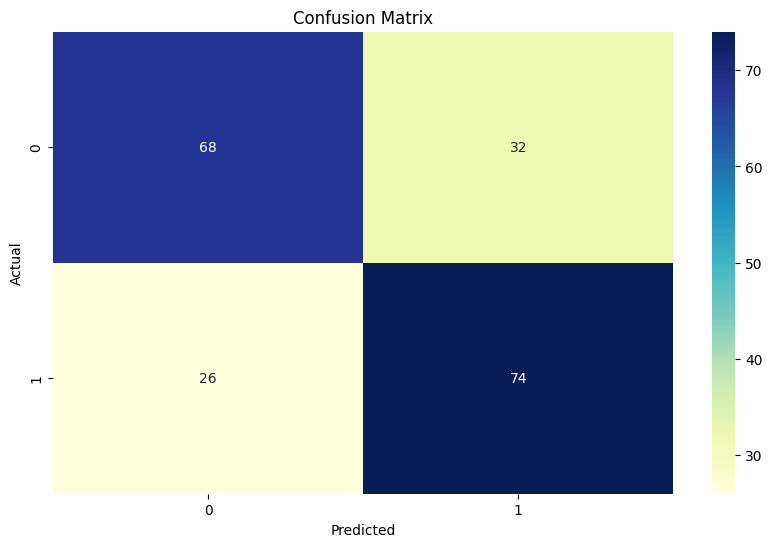

In [73]:
y_train_pred_knn_gridsearch = knn_gridsearch.predict(X_train)
y_test_pred_knn_gridsearch = knn_gridsearch.predict(X_test)

train_accuracy_knn_gridsearch = accuracy_score(y_train, y_train_pred_knn_gridsearch)
test_accuracy_knn_gridsearch = accuracy_score(y_test, y_test_pred_knn_gridsearch)

print(f"GRID SEARCH KNN MODEL:")
print(f"Train Accuracy: {train_accuracy_knn_gridsearch:.4f}")
print(f"Test Accuracy: {test_accuracy_knn_gridsearch:.4f}")
print(f"Overfitting Gap: {(train_accuracy_knn_gridsearch - test_accuracy_knn_gridsearch):.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train, y_train_pred_knn_gridsearch))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_knn_gridsearch))

cm = confusion_matrix(y_test, y_test_pred_knn_gridsearch)
print("\nConfusion Matrix:")
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

param_grid 1
- Fitting 5 folds for each of 54 candidates, totalling 270 fits
✓ Grid Search completed
- Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
- Best Score: 0.6725
- Train Accuracy: 1.0000
- Test Accuracy: 0.7100
- Overfitting Gap: 0.2900

param_grid 2
- Fitting 5 folds for each of 24 candidates, totalling 120 fits
✓ Grid Search completed
- Best Parameters:
{'leaf_size': 30, 'metric': 'minkowski', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
- Best Score: 0.6675
- Train Accuracy: 0.7612
- Test Accuracy: 0.6950
- Overfitting Gap: 0.0663

param_grid 3
- Fitting 5 folds for each of 18 candidates, totalling 90 fits
✓ Grid Search completed
- Best Parameters:
{'leaf_size': 30, 'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
- Best Score: 0.6638
- Train Accuracy: 0.7512
- Test Accuracy: 0.7100
- Overfitting Gap: 0.0413

# Model Evaluation and Interpretation

## Metrics


Model Comparison


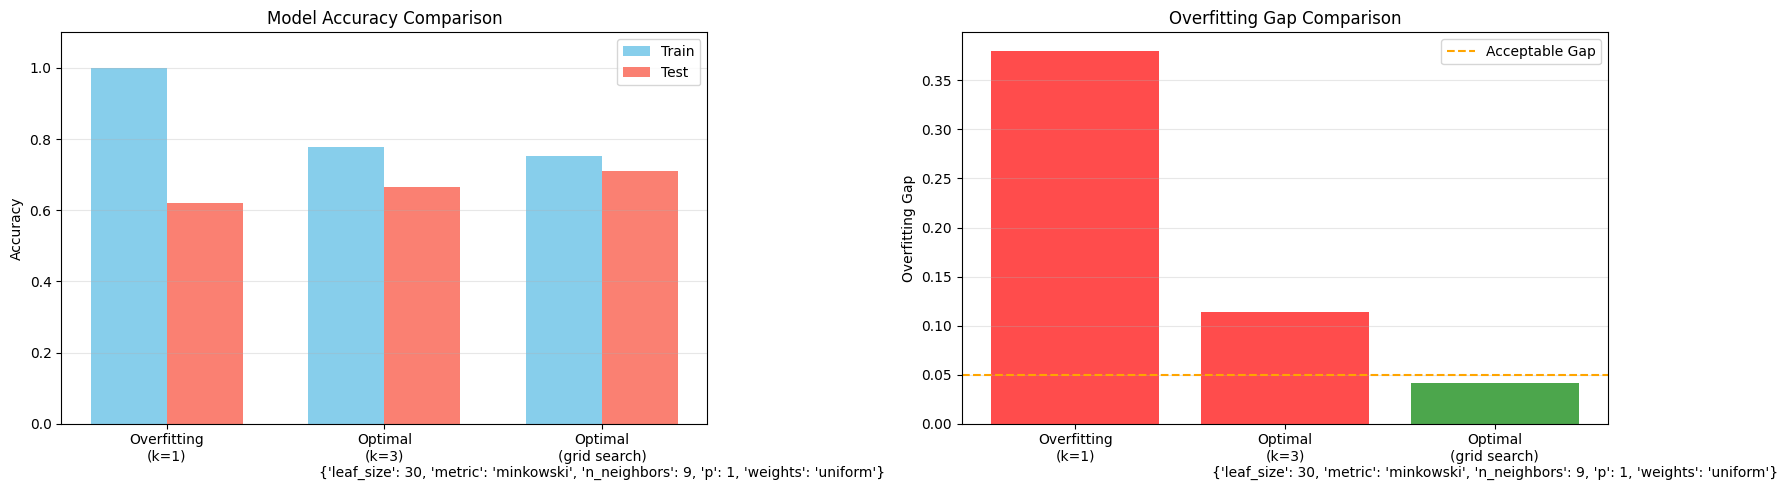

In [78]:
# Comparison visualisation

comparison_df = pd.DataFrame({
    "Model": ["Overfitting (k=1)", "Optimal (k=3)", "Optimal (grid search)"],
    "Train Accuracy": [train_accuracy_knn1, train_accuracy_knn_adjusted, train_accuracy_knn_gridsearch],
    "Test Accuracy": [test_accuracy_knn1, test_accuracy_knn_adjusted, test_accuracy_knn_gridsearch],
    "Overfitting Gap": [train_accuracy_knn1 - test_accuracy_knn1, train_accuracy_knn_adjusted - test_accuracy_knn_adjusted, train_accuracy_knn_gridsearch - test_accuracy_knn_gridsearch]
})

print("\nModel Comparison")
fig, axes = plt.subplots(1, 2, figsize=(18,5))

# Plot 1: accuracy comparison
models = ['Overfitting\n(k=1)', 'Optimal\n(k=3)', 'Optimal\n(grid search)\n' + str(grid_search.best_params_)]
train_accs = [train_accuracy_knn1, train_accuracy_knn_adjusted, train_accuracy_knn_gridsearch]
test_accs = [test_accuracy_knn1, test_accuracy_knn_adjusted, test_accuracy_knn_gridsearch]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Train', color='skyblue')
axes[0].bar(x + width/2, test_accs, width, label='Test', color='salmon')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim([0, 1.1])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: overfitting gap
gaps = [train_accuracy_knn1 - test_accuracy_knn1,
        train_accuracy_knn_adjusted - test_accuracy_knn_adjusted,
        train_accuracy_knn_gridsearch - test_accuracy_knn_gridsearch]

colors = ['red' if gap > 0.1 else 'green' for gap in gaps]
axes[1].bar(models, gaps, color=colors, alpha=0.7)
axes[1].set_ylabel('Overfitting Gap')
axes[1].set_title('Overfitting Gap Comparison')
axes[1].axhline(y=0.05, color='orange', linestyle='--', label='Acceptable Gap')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## LLMs to summarise findings, provide insights, and interpret feature importance


Calculating permutation importance...

Top 10 Most Important Features:
                 Feature  Importance      Std
              CustomerID      0.0660 0.028089
            InterestRate      0.0400 0.009487
             CreditScore      0.0320 0.008124
   EmploymentLengthYears      0.0310 0.008307
           ExistingLoans      0.0260 0.011136
                     Age      0.0235 0.012258
           MonthlyIncome      0.0225 0.012698
EmploymentType_Full-Time      0.0185 0.007089
             MonthlyDebt      0.0135 0.010966
EmploymentType_Part-Time      0.0130 0.005568



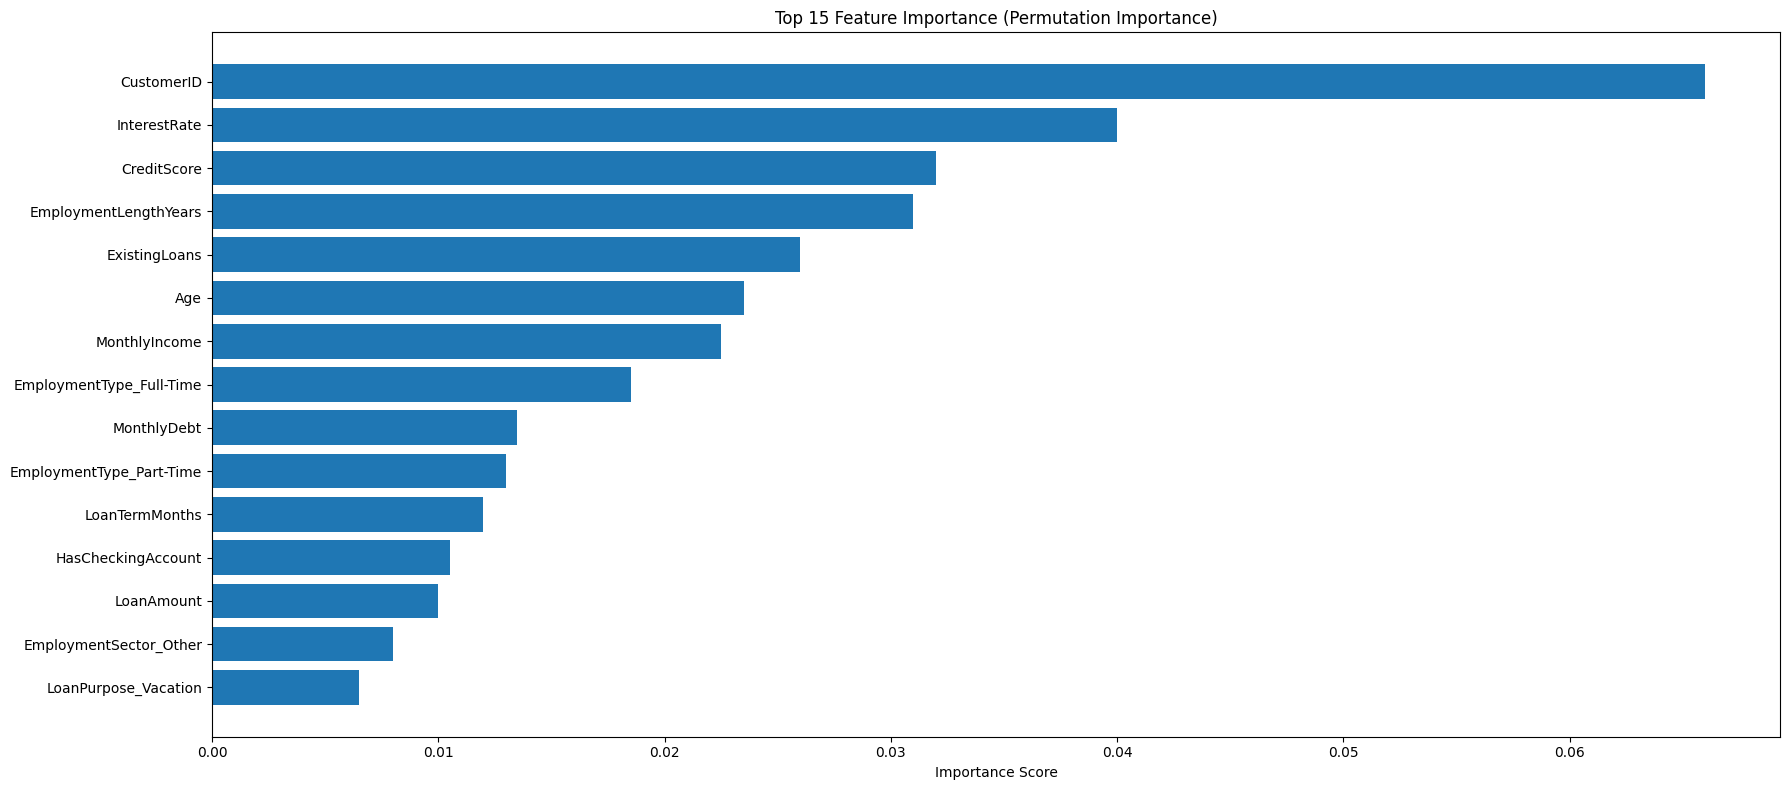

In [80]:
# Calculate feature importance using permutation importance
from sklearn.inspection import permutation_importance

print("\nCalculating permutation importance...")
perm_importance = permutation_importance(
    knn_gridsearch, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10).to_string(index=False))

# Visualize feature importance
print()
plt.figure(figsize=(18, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importance (Permutation Importance)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(drive_folder, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

In [82]:
# Prepare data for llm interpretation

# Gather all key statistics
model_stats = {
    'overfitting_model': {
        'k': 1,
        'train_acc': train_accuracy_knn1,
        'test_acc': test_accuracy_knn1,
        'gap': train_accuracy_knn1 - test_accuracy_knn1
    },
    'manual_model': {
        'k': 3,
        'train_acc': train_accuracy_knn_adjusted,
        'test_acc': test_accuracy_knn_adjusted,
        'gap': train_accuracy_knn_adjusted - test_accuracy_knn_adjusted
    },
    'optimal_model': {
        'params': grid_search.best_params_,
        'train_acc': train_accuracy_knn_gridsearch,
        'test_acc': test_accuracy_knn_gridsearch,
        'gap': train_accuracy_knn_gridsearch - test_accuracy_knn_gridsearch,
        'cv_score': grid_search.best_score_
    }
}

# Get classification report for optimal model
from sklearn.metrics import classification_report
test_report = classification_report(y_test, y_test_pred_knn_gridsearch, output_dict=True)

In [83]:
print("Loading LLM for interpretation...")

model_name = "mistralai/Mistral-7B-Instruct-v0.1"
quant_config = BitsAndBytesConfig(load_in_4bit=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, token=HUGGINGFACE_TOKEN)
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=quant_config, token=HUGGINGFACE_TOKEN)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("✓ LLM loaded successfully!")

Loading LLM for interpretation...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ LLM loaded successfully!


In [85]:
# ============================================================================
# PROMPT 1: MODEL PERFORMANCE SUMMARY
# ============================================================================

print("\n" + "="*80)
print("PROMPT 1: MODEL PERFORMANCE SUMMARY & OVERFITTING ANALYSIS")
print("="*80)

prompt1 = f"""You are a data science expert analyzing a loan default prediction model.

I trained three KNN models to predict loan defaults:

1. OVERFITTING MODEL (k=1):
   - Training Accuracy: {model_stats['overfitting_model']['train_acc']:.4f}
   - Test Accuracy: {model_stats['overfitting_model']['test_acc']:.4f}
   - Overfitting Gap: {model_stats['overfitting_model']['gap']:.4f}

2. MANUALLY ADJUSTED MODEL (k=3):
   - Training Accuracy: {model_stats['manual_model']['train_acc']:.4f}
   - Test Accuracy: {model_stats['manual_model']['test_acc']:.4f}
   - Overfitting Gap: {model_stats['manual_model']['gap']:.4f}

3. GRID SEARCH OPTIMIZED MODEL:
   - Best Parameters: {model_stats['optimal_model']['params']}
   - Training Accuracy: {model_stats['optimal_model']['train_acc']:.4f}
   - Test Accuracy: {model_stats['optimal_model']['test_acc']:.4f}
   - Cross-Validation Score: {model_stats['optimal_model']['cv_score']:.4f}
   - Overfitting Gap: {model_stats['optimal_model']['gap']:.4f}

Provide a concise analysis (3-4 sentences) covering:
1. Why the k=1 model overfits
2. How optimization improved generalization
3. Which model performs best and why"""

try:
    input1 = tokenizer(prompt1, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
    output1 = model.generate(**input1, max_new_tokens=300, temperature=0.7, do_sample=True)
    llm_interpretation1 = tokenizer.decode(output1[0], skip_special_tokens=True)

    # Extract only the response (remove the prompt)
    response1 = llm_interpretation1.split("3. Which model performs best and why")[-1].strip()

    print(f"\n🤖 LLM Analysis:\n{llm_interpretation1}")
except Exception as e:
    print(f"Error: {e}")
    llm_interpretation1 = "Error generating interpretation."

# ============================================================================
# PROMPT 2: FEATURE IMPORTANCE INTERPRETATION
# ============================================================================

print("\n" + "="*80)
print("PROMPT 2: FEATURE IMPORTANCE INTERPRETATION")
print("="*80)

top_5_features = feature_importance_df.head(5)
feature_list = "\n".join([f"{i+1}. {row['Feature']}: {row['Importance']:.4f}"
                          for i, row in top_5_features.iterrows()])

prompt2 = f"""You are a financial risk analyst interpreting a loan default prediction model.

The top 5 most important features for predicting loan defaults are:
{feature_list}

Based on these features, provide insights (3-4 sentences) on:
1. What these features tell us about default risk
2. Business implications for loan approval decisions
3. Risk factors lenders should monitor"""

try:
    input2 = tokenizer(prompt2, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
    output2 = model.generate(**input2, max_new_tokens=300, temperature=0.7, do_sample=True)
    llm_interpretation2 = tokenizer.decode(output2[0], skip_special_tokens=True)

    # Extract only the response
    response2 = llm_interpretation2.split("3. Risk factors lenders should monitor")[-1].strip()

    print(f"\n🤖 LLM Analysis:\n{llm_interpretation2}")
except Exception as e:
    print(f"Error: {e}")
    llm_interpretation2 = "Error generating interpretation."

# ============================================================================
# PROMPT 3: MODEL PERFORMANCE METRICS INTERPRETATION
# ============================================================================

print("\n" + "="*80)
print("PROMPT 3: CLASSIFICATION METRICS INTERPRETATION")
print("="*80)

prompt3 = f"""You are a machine learning expert analyzing classification metrics for a loan default model.

Classification Report (Optimal Model):
- Class 0 (No Default): Precision={test_report['0']['precision']:.3f}, Recall={test_report['0']['recall']:.3f}, F1={test_report['0']['f1-score']:.3f}
- Class 1 (Default): Precision={test_report['1']['precision']:.3f}, Recall={test_report['1']['recall']:.3f}, F1={test_report['1']['f1-score']:.3f}
- Overall Accuracy: {test_report['accuracy']:.3f}

Context: Class 1 (default) is more critical to predict correctly as missing defaults is costly for banks.

Analyze (3-4 sentences):
1. Is the model better at identifying defaults or non-defaults?
2. What are the business implications of false positives vs false negatives?
3. Should we optimize for precision or recall?"""

try:
    input3 = tokenizer(prompt3, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
    output3 = model.generate(**input3, max_new_tokens=300, temperature=0.7, do_sample=True)
    llm_interpretation3 = tokenizer.decode(output3[0], skip_special_tokens=True)

    # Extract only the response
    response3 = llm_interpretation3.split("3. Should we optimize for precision or recall?")[-1].strip()

    print(f"\n🤖 LLM Analysis:\n{llm_interpretation3}")
except Exception as e:
    print(f"Error: {e}")
    llm_interpretation3 = "Error generating interpretation."

# ============================================================================
# PROMPT 4: RECOMMENDATIONS & NEXT STEPS
# ============================================================================

print("\n" + "="*80)
print("PROMPT 4: RECOMMENDATIONS & NEXT STEPS")
print("="*80)

prompt4 = f"""You are a senior data scientist providing recommendations for a loan default prediction system.

Current Model Performance:
- Test Accuracy: {model_stats['optimal_model']['test_acc']:.3f}
- Overfitting Gap: {model_stats['optimal_model']['gap']:.3f}
- Default Class F1-Score: {test_report['1']['f1-score']:.3f}

Top Important Features: {', '.join(top_5_features['Feature'].head(3).tolist())}

Provide actionable recommendations (4-5 points) covering:
1. Model improvements (algorithms, ensemble methods)
2. Feature engineering opportunities
3. Business deployment considerations
4. Risk management strategies"""

try:
    input4 = tokenizer(prompt4, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
    output4 = model.generate(**input4, max_new_tokens=400, temperature=0.7, do_sample=True)
    llm_interpretation4 = tokenizer.decode(output4[0], skip_special_tokens=True)

    # Extract only the response
    response4 = llm_interpretation4.split("4. Risk management strategies")[-1].strip()

    print(f"\n🤖 LLM Recommendations:\n{llm_interpretation4}")
except Exception as e:
    print(f"Error: {e}")
    llm_interpretation4 = "Error generating interpretation."

print("\n" + "="*80)
print("LLM INTERPRETATION PIPELINE COMPLETED!")
print("="*80)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



PROMPT 1: MODEL PERFORMANCE SUMMARY & OVERFITTING ANALYSIS


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



🤖 LLM Analysis:
You are a data science expert analyzing a loan default prediction model. 

I trained three KNN models to predict loan defaults:

1. OVERFITTING MODEL (k=1):
   - Training Accuracy: 1.0000
   - Test Accuracy: 0.6200
   - Overfitting Gap: 0.3800

2. MANUALLY ADJUSTED MODEL (k=3):
   - Training Accuracy: 0.7788
   - Test Accuracy: 0.6650
   - Overfitting Gap: 0.1138

3. GRID SEARCH OPTIMIZED MODEL:
   - Best Parameters: {'leaf_size': 30, 'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
   - Training Accuracy: 0.7512
   - Test Accuracy: 0.7100
   - Cross-Validation Score: 0.6638
   - Overfitting Gap: 0.0413

Provide a concise analysis (3-4 sentences) covering:
1. Why the k=1 model overfits
2. How optimization improved generalization
3. Which model performs best and why.

1. The k=1 model overfits because the neighboring points are too similar to the target point, as k=1 does not allow for different weights to be assigned to different neighbors.
2. Opt

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



🤖 LLM Analysis:
You are a financial risk analyst interpreting a loan default prediction model.

The top 5 most important features for predicting loan defaults are:
1. CustomerID: 0.0660
15. InterestRate: 0.0400
7. CreditScore: 0.0320
4. EmploymentLengthYears: 0.0310
8. ExistingLoans: 0.0260

Based on these features, provide insights (3-4 sentences) on:
1. What these features tell us about default risk
2. Business implications for loan approval decisions
3. Risk factors lenders should monitor

1. What these features tell us about default risk:
The loan default prediction model indicates that CustomerID, InterestRate, CreditScore, EmploymentLengthYears, and ExistingLoans are the top 5 most important features for predicting loan defaults. This suggests that these features have a significant impact on the likelihood of a borrower defaulting on their loan. Specifically, a lower CreditScore, higher InterestRate, shorter EmploymentLengthYears, and more ExistingLoans are associated with a hig

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



🤖 LLM Analysis:
You are a machine learning expert analyzing classification metrics for a loan default model.

Classification Report (Optimal Model):
- Class 0 (No Default): Precision=0.723, Recall=0.680, F1=0.701
- Class 1 (Default): Precision=0.698, Recall=0.740, F1=0.718
- Overall Accuracy: 0.710

Context: Class 1 (default) is more critical to predict correctly as missing defaults is costly for banks.

Analyze (3-4 sentences):
1. Is the model better at identifying defaults or non-defaults?
2. What are the business implications of false positives vs false negatives?
3. Should we optimize for precision or recall?

### Answer:

1. The model is better at identifying defaults with a precision of 0.698 and recall of 0.740, compared to no defaults with a precision of 0.723 and recall of 0.680.
2. False positives (predicting a default when it does not exist) can result in banks losing revenue from incorrectly charging interest and fees. False negatives (failing to predict a default when it 